# Lecture 11

## Intro to Deep learning using Pytorch

 PyTorch provides **tensors**, which are similar to NumPy arrays but can also live on GPUs for fast computation. 
- PyTorch provides **automatic differentiation** (`autograd`), which makes it possible to compute gradients needed for training neural networks.
- PyTorch provides the `nn.Module` framework for defining neural networks as Python classes.
- PyTorch also provides tools for **datasets** and **data loaders**, which help organize training data and iterate over it in batches.

### Import packages 

- To install PyTorch in your environment, first activate the environment and then use pip.
- Check the PyTorch website for the exact installation command [https://pytorch.org/get-started/locally/](https://pytorch.org/get-started/locally/)

In [63]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# To isntall torch in your envirnment use pip after activating your envirnment.
# CHekc this url for exact command

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
import torchvision
import warnings
warnings.filterwarnings('ignore')

The "XOR" (or "exclusive OR") problem is often used to illustrate the ability of neural networks to fit complicated functions. The XOR problem has a checkerboard structure:

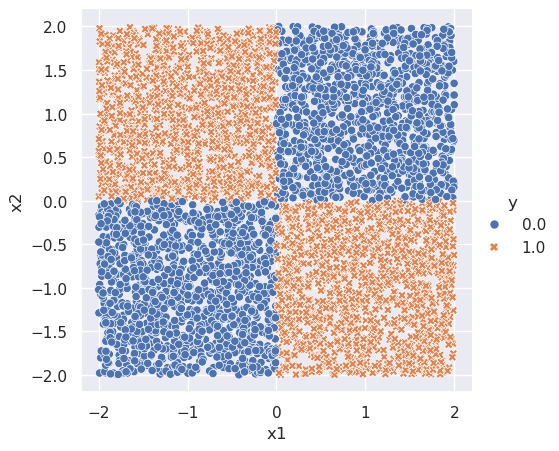

In [64]:
# xor ------------------------------------
n = 5000
p = 2
x = np.random.uniform(-2, 2, size=(n, p))

y = ((x[:,0] < 0) & (x[:, 1] > 0)).astype(x.dtype) + ((x[:,0] > 0) & (x[:, 1] < 0)).astype(x.dtype)

df = np.hstack([y.reshape((n, 1)), x])
df = pd.DataFrame(df, columns = ['y', 'x1', 'x2'])

sns.set_theme()
xor_plot = sns.relplot(df, x='x1', y='x2', hue='y', style='y')
plt.subplots_adjust(top=.9)

Logistic regression can only fit linear decision boundaries, and so fails the XOR problem.

In [65]:
# Fit logistic regression
log_fit = LogisticRegression()
log_fit.fit(x, y)

# Predictions
y_prob = log_fit.predict_proba(x)[:,1]
y_pred = log_fit.predict(x)

# Data for plotting
df_plot = df.copy()
df_plot["y_pred"] = y_pred

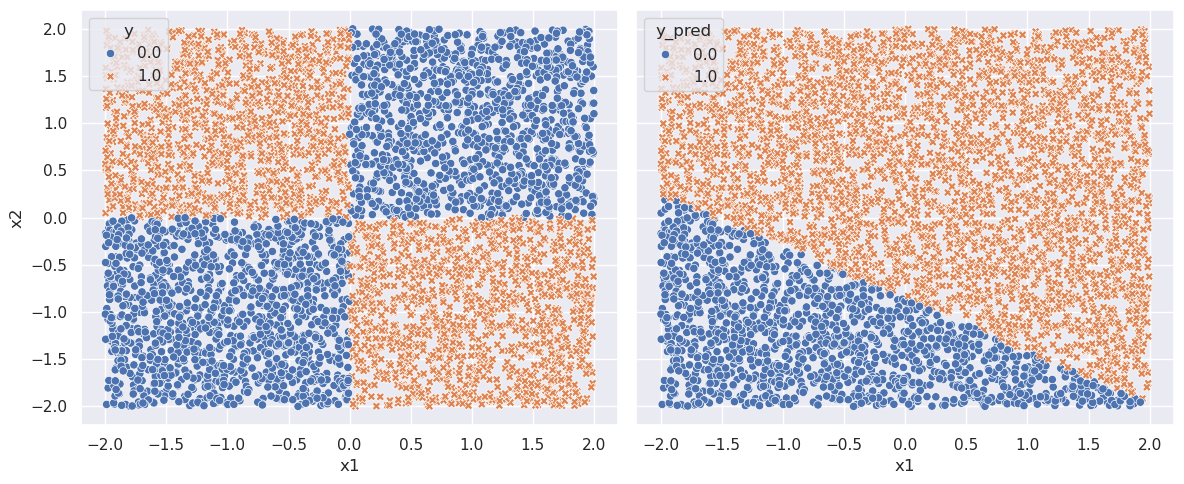

In [66]:
# Plot
sns.set_theme()
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Left: true labels
sns.scatterplot(
    data=df_plot, x="x1", y="x2", hue="y", style="y", ax=axes[0]
)

# Right: predicted labels
sns.scatterplot(
    data=df_plot, x="x1", y="x2", hue="y_pred", style="y_pred", ax=axes[1]
)


plt.tight_layout()
plt.show()

### Feed-forward fully connected neural networks

Most basic neural networks are built by stacking linear transformations and fixed nonlinear activation functions such as the sigmoid, ReLU, or tanh.

Single hidden layer NN: 

$$
f_{\theta}(x) = f_{W_2, W_1, b_1, b_2}(x) = \sigma\left( W_2 \, \sigma(W_1 x + b_1) + b_2 \right),
$$
where $\sigma(x) = \sigma(x) = \frac{1}{1 + e^{-x}}$

### Fitting to the data

Expanded expression:

$$
h_j = \sigma\left( \beta_{j0} + \beta_{j1}x_1 + \cdots + \beta_{jp}x_p \right), \qquad j=1,\dots,m
$$

$$
f(x) = \sigma\left( \alpha_0 + \alpha_1 h_1 + \cdots + \alpha_m h_m \right)
$$

Given a training set $(y_i, x_i)$, neural network are fit to the data by minimizing a **loss function**

$$
\hat{\theta} = \arg\min_{\theta} \sum_{i=1}^n L\big(y_i, f_{\theta}(x_i))\big)
$$

<div style="text-align: center;">
  <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTNqdh7oprmD-9ilwB-_dajI17FWHDAA9rX1Q&s" width="200">
</div>

### Pytorch: building blocks

PyTorch defines `nn.Linear`, which allows linear transformation $$y = xA^T + b$$ in an object-oriented style.

In [67]:
linear_layer = nn.Linear(in_features = 2, out_features = 1)
print(f"A: {linear_layer.weight}\n") # This is the matrix A, initialized at random
print(f"b: {linear_layer.bias}\n") # This is the vector b, initialized at random

x_train = torch.tensor(x, dtype=torch.float)
y_train = torch.tensor(y, dtype=torch.float)

#Equal to: x_train@linear_layer.weight.T + linear_layer.bias
output_linear = linear_layer(x_train)
print(f"xA^T + b:\n {output_linear}")


A: Parameter containing:
tensor([[ 0.4752, -0.1279]], requires_grad=True)

b: Parameter containing:
tensor([-0.3602], requires_grad=True)

xA^T + b:
 tensor([[-0.9807],
        [-0.3951],
        [ 0.3402],
        ...,
        [-0.8808],
        [ 0.1630],
        [-0.2756]], grad_fn=<AddmmBackward0>)


PyTorch defines `nn.Sigmoid`, which applies the sigmoid transformation in an object-oriented style.

In [68]:
sigmoid_layer = nn.Sigmoid()

# Equivalent to applying the sigmoid function elementwise:
# sigma(z) = 1 / (1 + exp(-z))
output_sigmoid = sigmoid_layer(output_linear)
y_pred = output_sigmoid.flatten()

print(f"\sigma(xA^T + b):\n {y_pred}")

\sigma(xA^T + b):
 tensor([0.2728, 0.4025, 0.5842,  ..., 0.2930, 0.5407, 0.4315],
       grad_fn=<ViewBackward0>)


Check fit to the data. PyTorch defines several loss functions. This is a classification problem, so we use the same loss function as logistic regression (Binary Cross Entropy loss)

$$
\ell(y, \hat{y}) = - \left[ y \log(\hat{y}) + (1-y)\log(1-\hat{y}) \right]
$$

In [69]:
loss_fn = torch.nn.BCELoss(reduction="sum") # Binary Cross Entropy loss, checks how far your predictions are from true values

loss = loss_fn(y_pred, y_train)

print(f"Loss value is: {loss.item()}")

Loss value is: 3750.666259765625


### Gradient-based minimization

Neural networks are typically fit using **gradient descent** or one of its variants.

Starting from an initial guess $\theta^{(0)}$, gradient descent updates the parameters iteratively according to

$$
\theta^{(t+1)} = \theta^{(t)} - \eta \nabla \left[ \sum_{i=1}^n L\big(y_i, f(x_i; \theta^{(t)})\big) \right]
$$

where $\eta > 0$ is the **learning rate** and $\nabla$ denotes the gradient with respect to the parameters. The gradient points in the direction of steepest increase of the loss, so subtracting it moves the parameters in a direction that reduces the loss.

**What is so powerful about PyTorch? Automatic gradient computation.**

In [83]:
loss = loss_fn(y_pred, y_train)
loss.backward() # This command allows you to compute the gradient of all unkown parameters

print(f"Gradient for weight linear module: {linear_layer.weight.grad}")
print(f"Gradient for bias linear module: {linear_layer.bias.grad}")


Gradient for weight linear module: tensor([[262.5147, -96.6214]])
Gradient for bias linear module: tensor([-226.2901])


In [84]:
# Manual gradient descent step. Idea update weight in the direction suggested by gradients.
learning_rate = 0.0001

with torch.no_grad():  #tells PyTorch not to track gradients for the operations inside that block (gradients have already been computed by now)
    linear_layer.weight -= learning_rate * linear_layer.weight.grad
    linear_layer.bias -= learning_rate * linear_layer.bias.grad

# Clear gradients before next backward pass
linear_layer.weight.grad = None
linear_layer.bias.grad = None

# Recompute predictions after the update
output_linear = linear_layer(x_train)
output_sigmoid = sigmoid_layer(output_linear)
y_pred = output_sigmoid.flatten()

loss = loss_fn(y_pred, y_train)
print(f"Loss after update is: {loss.item()}")

# Idea: Repeat this step procedure iteratively 
#  - Compute gradient
#  - Update paramters
# until loss function reaches ``small'' stable value

# Try it for yourself (keep running the last two blocks)

Loss after update is: 3495.0029296875


### How to best use PyTorch: Define a class for your neural network

The code above was meant only to illustrate the basic idea. In practice, PyTorch code is usually organized by defining a class that combines all the operations of a neural network into a single object.

When we define a neural network in PyTorch, we typically create a **subclass** of `nn.Module`. In other words, our class **inherits** from `nn.Module`.

By inheriting from `nn.Module`, our class gets useful built-in behavior, such as:

- storing model parameters
- working with optimizers
- switching between training and evaluation mode
- integrating naturally with the rest of PyTorch

This is a good example of **inheritance**: we build our own class on top of an existing one.

Here is an example of a neural network in `torch` called `XORNet`.

In [ ]:
# Single hidden layer neural network

class XORNet(nn.Module): # Name of the class (neural network model) inheriting nn.Module

    def __init__(self, input_dim, hidden_dim): # Initializer (think of hyperparamters as in scikit learn)
        super(XORNet, self).__init__() # Call initializer of nn.Module
        
        self.linear1 =  nn.Linear(input_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):  # The function `forward` is called when the neural network is run on input data.
        out_1 = self.linear1(x) # output is samples x 1 matrix
        out_2 = self.sigmoid(out_1)
        out_3 = self.linear2(out_2)
        out_4 = self.sigmoid(out_3)
        y = torch.flatten(out_4) # output is samples vector
        return y

In [86]:
hidden_dim=10
model = XORNet(input_dim=p, hidden_dim=hidden_dim)

In [87]:
model

XORNet(
  (linear1): Linear(in_features=2, out_features=10, bias=True)
  (linear2): Linear(in_features=10, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Apply to data:

In [88]:
x_train = torch.tensor(x, dtype=torch.float)
y_train = torch.tensor(y, dtype=torch.float)

In [89]:
loss_fn = torch.nn.BCELoss(reduction="sum") 

# Apply nueral network (with random weights to data)
ypred = model(x_train)
cur_loss = loss_fn(ypred, y_train)
print(ypred.shape)
print(cur_loss)

torch.Size([5000])
tensor(3603.0820, grad_fn=<BinaryCrossEntropyBackward0>)


### Data: Best practice is to use `TensorDataset` and `DataLoader`

We combine `x_train` and `y_train` into a `TensorDataset`, a dataset recognizable by torch. `TensorDataset` stores the samples and their labels. It is a subclass of the more general `torch.utils.data.Dataset`, which you can customize for non-standard data.

In [90]:
train_data = TensorDataset(x_train, y_train)

In [91]:
x_temp, y_temp = train_data[0]

In [92]:
x_temp

tensor([-1.8389, -1.9797])

`TensorDataset` is helpful as it can be passed to `DataLoader()`. `DataLoader` wraps an iterable around the `Dataset` class to enable easy access to the samples. This is very helpful for implementing stochastic gradient descent, where we iterate over subsets (batches) of the data.

This allows you to easily implement stochastic gradient descent, where the idea is to compute gradients from subsets of your data and introduce randomness that can help escape local minima.

In [93]:
train_loader = DataLoader(dataset=train_data, batch_size=10, shuffle=True)

### Training
We now set up the optimizer for training. We use Adam, and a base learning rate of `lr=0.01`. We set the number of epochs to 100. (Rule of thumb: pick largest `lr` that still results in convergence)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Use cpu or gpu based on whether the latter is available

lr = 0.01 # learning rate
epochs = 300 # How many passes of the full dataset (think "iterations of gradient descent")

optimizer = optim.Adam(model.parameters(), lr=lr)
loss_bce = torch.nn.BCELoss(reduction="sum") 


# set model to training mode
model.train()

XORNet(
  (linear1): Linear(in_features=2, out_features=10, bias=True)
  (linear2): Linear(in_features=10, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Now we train the model:

In [58]:
for epoch in range(epochs):
    
    # in each epoch, iterate over all batches of data (easily accessed through train_loader)
    epoch_loss = 0

    for x_batch, y_batch in train_loader:

        # calculate gradient over batch

        pred = model(x_batch)                   # this is the output from the forward function
        loss = loss_bce(pred, y_batch)           # calculate loss function

        loss.backward()                         # computes gradients wrt loss function

        # update parameters in direction of gradient

        optimizer.step()                        # updates parameters 

        optimizer.zero_grad()                   # set the gradients back to zero (otherwise grads are accumulated)

        epoch_loss += loss.item()               # grabs just numeric value of loss

    if epoch % 10 == 0:
        print('epoch: ', epoch, 'loss:', f"{epoch_loss:.3}")


epoch:  0 loss: 3.03e+03
epoch:  10 loss: 4e+02
epoch:  20 loss: 2.7e+02
epoch:  30 loss: 1.98e+02
epoch:  40 loss: 1.67e+02
epoch:  50 loss: 1.52e+02
epoch:  60 loss: 1.42e+02
epoch:  70 loss: 1.33e+02
epoch:  80 loss: 1.26e+02
epoch:  90 loss: 1.22e+02
epoch:  100 loss: 1.17e+02
epoch:  110 loss: 1.12e+02
epoch:  120 loss: 1.08e+02
epoch:  130 loss: 1.07e+02
epoch:  140 loss: 1.07e+02
epoch:  150 loss: 1.02e+02
epoch:  160 loss: 1e+02
epoch:  170 loss: 99.2
epoch:  180 loss: 99.3
epoch:  190 loss: 95.4
epoch:  200 loss: 95.7
epoch:  210 loss: 92.0
epoch:  220 loss: 89.8
epoch:  230 loss: 91.2
epoch:  240 loss: 88.5
epoch:  250 loss: 91.9
epoch:  260 loss: 85.9
epoch:  270 loss: 87.8
epoch:  280 loss: 82.8
epoch:  290 loss: 85.0


To visualize the end result, we plot the predicted values over the whole space (the decision surface).

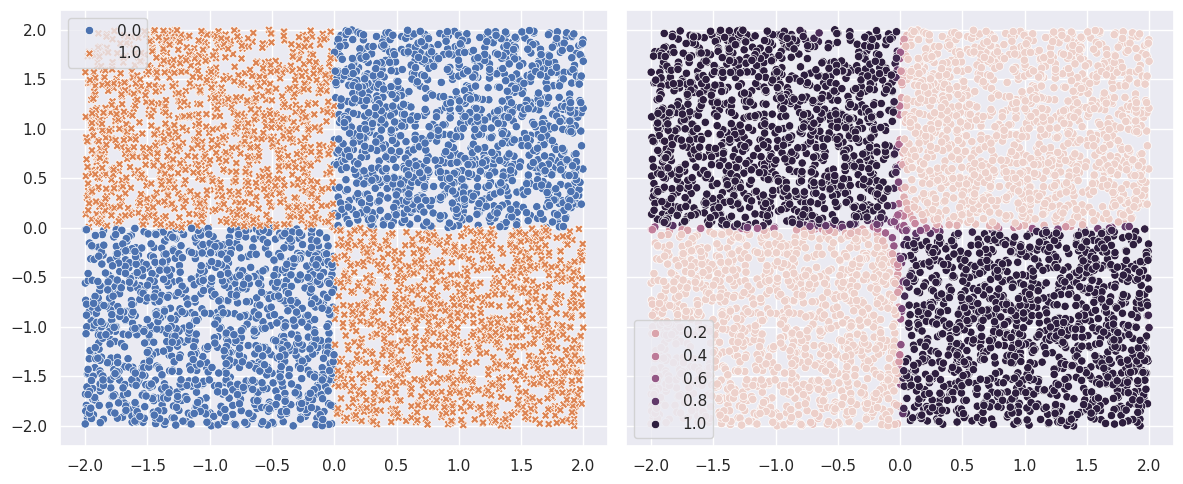

In [59]:
x1 = np.arange(-2, 2, 0.05)
x2 = np.arange(-2, 2, 0.05)


model.eval() # Make it clear that you are doing with training
y_pred = model(x_train) # Evaluate data
y_pred_prob_np = y_pred.detach().numpy()
y_pred_label_np = y_pred_prob_np>0.5


sns.set_theme()
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Left: true labels
sns.scatterplot(
    x=x[:,0], y=x[:,1], hue=y, style=y, ax=axes[0]
)

# Right: predicted labels
sns.scatterplot(
    x=x[:,0], y=x[:,1], hue=y_pred_prob_np, ax=axes[1]
)


plt.tight_layout()
plt.show()

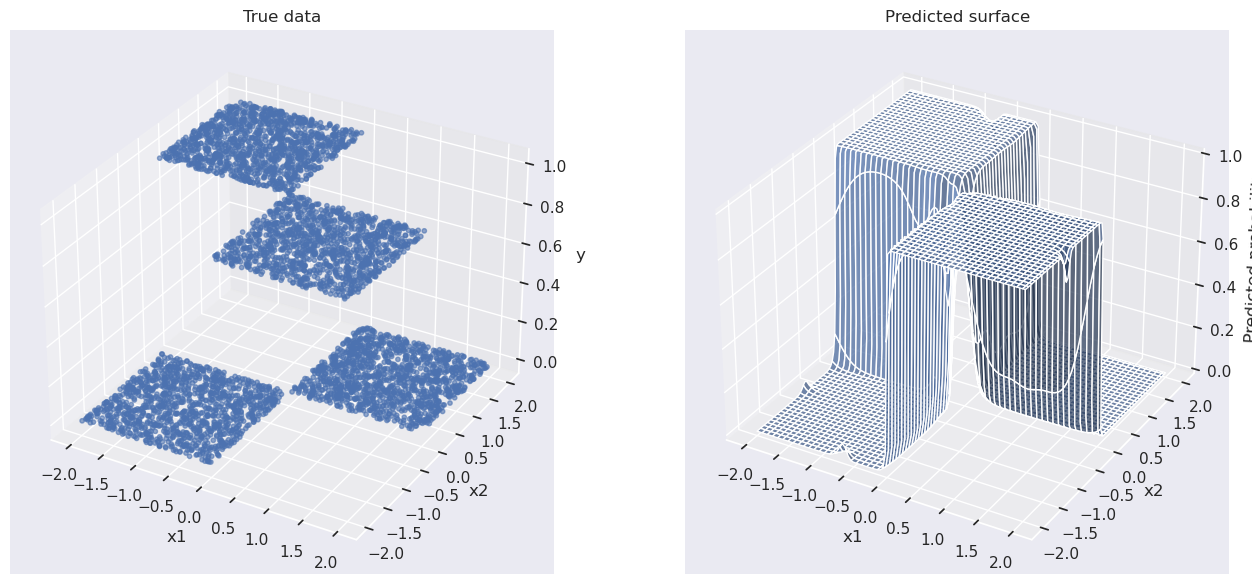

In [60]:
# 3D version of the same plot

fig = plt.figure(figsize=(14, 6))

# Left panel: true data
ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(
    x[:, 0],
    x[:, 1],
    y,
    s=10,
    alpha=0.6
)
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_zlabel("y")
ax1.set_title("True data")

# Create grid over x1-x2 space
x1_grid = np.linspace(x[:, 0].min(), x[:, 0].max(), 100)
x2_grid = np.linspace(x[:, 1].min(), x[:, 1].max(), 100)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

grid = np.column_stack([X1.ravel(), X2.ravel()])

# Predict on grid
# If using sklearn:
Z = model(torch.tensor(grid, dtype=torch.float)).detach().numpy()

# If using PyTorch instead, use something like:
# with torch.no_grad():
#     grid_tensor = torch.tensor(grid, dtype=torch.float32).to(device)
#     Z = model(grid_tensor).detach().cpu().numpy()

Z = Z.reshape(X1.shape)

# Right panel: predicted surface
ax2 = fig.add_subplot(122, projection="3d")
ax2.plot_surface(
    X1, X2, Z,
    alpha=0.7
)
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
ax2.set_zlabel("Predicted probability")
ax2.set_title("Predicted surface")

plt.tight_layout()
plt.show()

Play around with different sizes of `hidden_dim` and see the difference!